#  Моделирование связи частотного и классического определения вероятности

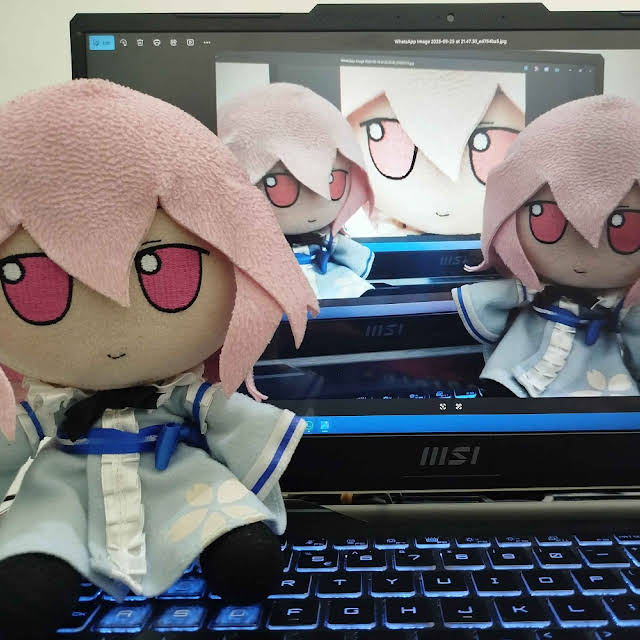

In [27]:
import scipy.special as sc
import numpy as np
import plotly.graph_objs as go
from random import sample

## Классическое решение

* Пусть А - из первой урны вытащили 3 белых
* Пусть B - из первой урны вытащили 2 белых и 1 черную
* Пусть C - из первой урны вытащили 1 белую и 2 черных
* Пусть D - из первой урны вытащили 3 черных

Тогда вероятности этих событий равны:

In [40]:
p_a = sc.comb(15, 3)/sc.comb(20, 3)
p_b = sc.comb(15, 2)*5/sc.comb(20, 3)
p_c = sc.comb(5, 2)*15/sc.comb(20, 3)
p_d = sc.comb(5, 3)/sc.comb(20, 3)
print(p_a, p_b, p_c, p_d)

0.3991228070175439 0.4605263157894737 0.13157894736842105 0.008771929824561403


Тогда вероятность достать белый шар из 2 урны равна сумме произведений вероятностей событий A, B, C, D на вероятность, соответствующую событию, вытащить белый шар

In [41]:
p = p_a * 0.9 + p_b * 0.8 + p_c * 0.7 + p_d * 0.6
p

np.float64(0.825)

---

## Моделирование решения

In [38]:
N_values = np.array(range(10, 10001, 50))
probs = []
for N in N_values:
    cnt = 0
    for _ in range(N):
        urna1 = ['Б'] * 15 + ['Ч'] * 5
        urna2 = ['Б'] * 6 + ['Ч']
        
        urna2.extend(sample(urna1, 3))
        if sample(urna2, 1)[0] == 'Б':
            cnt += 1
    probs.append(cnt / N)

p = [0.825] * len(probs)

print(round(probs[-1], 4))

0.8261


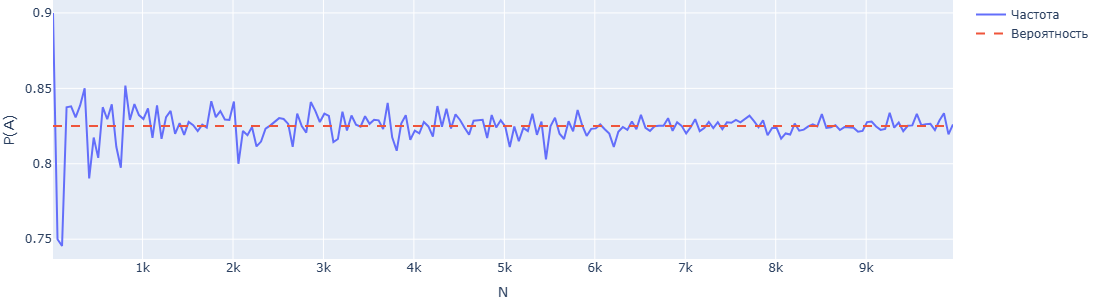

In [39]:
fig = go.Figure(layout=dict(width=600, height=300))
fig.update_layout(margin=dict(l=0, t=0, b=0))
fig.add_trace(go.Scatter(x=N_values, y=probs, name='Частота'))
fig.add_trace(go.Scatter(x=N_values, y=p, name='Вероятность', line_dash='dash'))
fig.update_xaxes(title_text='N')
fig.update_yaxes(title_text='P(A)')
fig.show();